In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = Path("data/road_event_history_v1.parquet")

df = pd.read_parquet(DATA_PATH)

print(df.shape)
df.head()

(9071717, 47)


,Segment_ID,Lifecycle_ID,event_date,year,event_type,event_order,Event_Idx,Measurement_Idx,ptm_idx,tp_idx,...,Toim_lk,Pituus,ELY,Tie,Ajorata,Kaista,Aosa,Aet,Losa,Let
0,Epo_13_0_11_102_4000_102_4071,None,2002-06-27,2002,TP,0,1,<NA>,NaN,6.0,...,valta,71,Epo,13,0,11,102,4000,102,4071
1,Epo_13_0_11_102_4000_102_4071,Epo_13_0_11_102_4000_102_4071_C0,2008-04-29,2008,PTM,1,2,1,13.0,NaN,...,valta,71,Epo,13,0,11,102,4000,102,4071
2,Epo_13_0_11_102_4000_102_4071,Epo_13_0_11_102_4000_102_4071_C0,2009-10-01,2009,TP,0,3,<NA>,NaN,5.0,...,valta,71,Epo,13,0,11,102,4000,102,4071
3,Epo_13_0_11_102_4000_102_4071,Epo_13_0_11_102_4000_102_4071_C0,2010-07-12,2010,TP,0,4,<NA>,NaN,4.0,...,valta,71,Epo,13,0,11,102,4000,102,4071
4,Epo_13_0_11_102_4000_102_4071,Epo_13_0_11_102_4000_102_4071_C1,2011-04-16,2011,PTM,1,5,1,12.0,NaN,...,valta,71,Epo,13,0,11,102,4000,102,4071


### Basic schema and quick overview

In [3]:
print("Shape:", df.shape)
print("\nColumns:")
for c in df.columns:
    print(" -", c)

print("\nDtypes:")
print(df.dtypes.sort_index())

print("\nMemory usage (MB):", round(df.memory_usage(deep=True).sum() / 1024**2, 2))

print("\nHead:")
display(df.head())

print("\nTail:")
display(df.tail())

Shape: (9071717, 47)

Columns:
 - Segment_ID
 - Lifecycle_ID
 - event_date
 - year
 - event_type
 - event_order
 - Event_Idx
 - Measurement_Idx
 - ptm_idx
 - tp_idx
 - IRI
 - URA
 - prev_IRI
 - prev_URA
 - delta_IRI
 - delta_URA
 - prev_meas_date
 - next_meas_date
 - Delta_t_days
 - Delta_t_years
 - days_since_prev_meas
 - days_until_next_meas
 - Pavement_Age_years
 - Initial_URA
 - tp_count_interval
 - has_TP_interval
 - is_minor_treatment
 - Minor_TP_Count
 - is_major_reset
 - is_phantom_reset
 - cycle_num
 - Tp_pinta
 - Tp_tyomen
 - KVL
 - KVL_raskas
 - KVL_kaista
 - Nopeus
 - Toim_lk
 - Pituus
 - ELY
 - Tie
 - Ajorata
 - Kaista
 - Aosa
 - Aet
 - Losa
 - Let

Dtypes:
Aet                              int64
Ajorata                          int64
Aosa                             int64
Delta_t_days                   float64
Delta_t_years                  float64
ELY                             object
Event_Idx                        int64
IRI                            float64
Initial_U

,Segment_ID,Lifecycle_ID,event_date,year,event_type,event_order,Event_Idx,Measurement_Idx,ptm_idx,tp_idx,...,Toim_lk,Pituus,ELY,Tie,Ajorata,Kaista,Aosa,Aet,Losa,Let
0,Epo_13_0_11_102_4000_102_4071,None,2002-06-27,2002,TP,0,1,<NA>,NaN,6.0,...,valta,71,Epo,13,0,11,102,4000,102,4071
1,Epo_13_0_11_102_4000_102_4071,Epo_13_0_11_102_4000_102_4071_C0,2008-04-29,2008,PTM,1,2,1,13.0,NaN,...,valta,71,Epo,13,0,11,102,4000,102,4071
2,Epo_13_0_11_102_4000_102_4071,Epo_13_0_11_102_4000_102_4071_C0,2009-10-01,2009,TP,0,3,<NA>,NaN,5.0,...,valta,71,Epo,13,0,11,102,4000,102,4071
3,Epo_13_0_11_102_4000_102_4071,Epo_13_0_11_102_4000_102_4071_C0,2010-07-12,2010,TP,0,4,<NA>,NaN,4.0,...,valta,71,Epo,13,0,11,102,4000,102,4071
4,Epo_13_0_11_102_4000_102_4071,Epo_13_0_11_102_4000_102_4071_C1,2011-04-16,2011,PTM,1,5,1,12.0,NaN,...,valta,71,Epo,13,0,11,102,4000,102,4071



Tail:


,Segment_ID,Lifecycle_ID,event_date,year,event_type,event_order,Event_Idx,Measurement_Idx,ptm_idx,tp_idx,...,Toim_lk,Pituus,ELY,Tie,Ajorata,Kaista,Aosa,Aet,Losa,Let
9071712,Var_9_2_21_103_700_103_800,Var_9_2_21_103_700_103_800_C2,2020-04-30,2020,PTM,1,13,3,4.0,NaN,...,valta,100,Var,9,2,21,103,700,103,800
9071713,Var_9_2_21_103_700_103_800,Var_9_2_21_103_700_103_800_C2,2021-04-22,2021,PTM,1,14,4,3.0,NaN,...,valta,100,Var,9,2,21,103,700,103,800
9071714,Var_9_2_21_103_700_103_800,Var_9_2_21_103_700_103_800_C2,2022-04-24,2022,PTM,1,15,5,2.0,NaN,...,valta,100,Var,9,2,21,103,700,103,800
9071715,Var_9_2_21_103_700_103_800,Var_9_2_21_103_700_103_800_C2,2023-04-06,2023,PTM,1,16,6,1.0,NaN,...,valta,100,Var,9,2,21,103,700,103,800
9071716,Var_9_2_21_103_700_103_800,Var_9_2_21_103_700_103_800_C2,2024-05-07,2024,TP,0,17,<NA>,NaN,1.0,...,valta,100,Var,9,2,21,103,700,103,800


### Normalize dtypes you likely want for inspection

In [4]:
date_cols = [
    "event_date",
    "prev_meas_date",
    "next_meas_date",
]

for c in date_cols:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

nullable_int_cols = [
    "year",
    "Event_Idx",
    "Measurement_Idx",
    "ptm_idx",
    "tp_idx",
    "tp_count_interval",
    "Minor_TP_Count",
    "cycle_num",
]

for c in nullable_int_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").astype("Int64")

print("Dtype normalization done.")

Dtype normalization done.


### Basic counts and event composition

In [5]:
print("Row count:", len(df))
print("Unique segments:", df["Segment_ID"].nunique() if "Segment_ID" in df.columns else "Segment_ID missing")
print("Unique lifecycles:", df["Lifecycle_ID"].nunique(dropna=True) if "Lifecycle_ID" in df.columns else "Lifecycle_ID missing")

if "event_type" in df.columns:
    print("\nEvent type counts:")
    display(df["event_type"].value_counts(dropna=False))

    print("\nEvent type proportions:")
    display(df["event_type"].value_counts(dropna=False, normalize=True).rename("proportion"))

if "year" in df.columns:
    print("\nYear range:", df["year"].min(), "->", df["year"].max())

Row count: 9071717
Unique segments: 1064380
Unique lifecycles: 1610446

Event type counts:


event_type
PTM    5515859
TP     3555858
Name: count, dtype: int64


Event type proportions:


event_type
PTM    0.608028
TP     0.391972
Name: proportion, dtype: float64


Year range: 1955 -> 2024


### Missing values summary

In [6]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
    "dtype": df.dtypes.astype(str),
})
missing = missing.sort_values(["missing_pct", "missing_count"], ascending=[False, False])

display(missing)

,missing_count,missing_pct,dtype
Tp_tyomen,6160449,67.908302,object
Tp_pinta,5782102,63.737681,object
tp_idx,5515859,60.802812,Int64
delta_IRI,4609919,50.816389,float64
prev_IRI,4606390,50.777488,float64
delta_URA,4605436,50.766972,float64
prev_URA,4605095,50.763213,float64
Delta_t_days,4604935,50.761449,float64
Delta_t_years,4604935,50.761449,float64
prev_meas_date,3955728,43.605064,datetime64[ns]


### Missing values by event type

In [7]:
if "event_type" not in df.columns:
    print("event_type column not found.")
else:
    out = []
    for ev_type, g in df.groupby("event_type", dropna=False):
        m = pd.DataFrame({
            "column": g.columns,
            "missing_count": g.isna().sum().values,
            "missing_pct": (g.isna().mean() * 100).values,
        })
        m["event_type"] = ev_type
        out.append(m)

    missing_by_type = pd.concat(out, ignore_index=True)
    missing_by_type = missing_by_type.sort_values(["event_type", "missing_pct"], ascending=[True, False])

    display(missing_by_type)

,column,missing_count,missing_pct,event_type
9,tp_idx,5515859,100.000000,PTM
31,Tp_pinta,5515859,100.000000,PTM
32,Tp_tyomen,5515859,100.000000,PTM
14,delta_IRI,1054061,19.109644,PTM
12,prev_IRI,1050532,19.045665,PTM
...,...,...,...,...
89,Kaista,0,0.000000,TP
90,Aosa,0,0.000000,TP
91,Aet,0,0.000000,TP
92,Losa,0,0.000000,TP


### Numeric summary statistics

In [8]:
num_cols = df.select_dtypes(include=[np.number, "Float64", "Int64"]).columns.tolist()

print("Numeric columns:", num_cols)
display(df[num_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T)

Numeric columns: ['year', 'event_order', 'Event_Idx', 'Measurement_Idx', 'ptm_idx', 'tp_idx', 'IRI', 'URA', 'prev_IRI', 'prev_URA', 'delta_IRI', 'delta_URA', 'Delta_t_days', 'Delta_t_years', 'days_since_prev_meas', 'days_until_next_meas', 'Pavement_Age_years', 'Initial_URA', 'tp_count_interval', 'Minor_TP_Count', 'cycle_num', 'KVL', 'KVL_raskas', 'KVL_kaista', 'Nopeus', 'Pituus', 'Tie', 'Ajorata', 'Kaista', 'Aosa', 'Aet', 'Losa', 'Let']


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
year,9071717.0,2009.80723,14.066273,1955.0,1967.0,1979.0,2004.0,2015.0,2020.0,2024.0,2024.0,2024.0
event_order,9071717.0,0.608028,0.48819,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0
Event_Idx,9071717.0,5.708719,3.927116,1.0,1.0,1.0,3.0,5.0,8.0,13.0,18.0,25.0
Measurement_Idx,5515859.0,2.859354,1.947946,1.0,1.0,1.0,1.0,2.0,4.0,7.0,9.0,15.0
ptm_idx,5515859.0,4.131958,2.957541,1.0,1.0,1.0,2.0,3.0,6.0,10.0,13.0,15.0
tp_idx,3555858.0,2.406524,1.272546,1.0,1.0,1.0,1.0,2.0,3.0,5.0,6.0,11.0
IRI,5510517.0,1.878937,1.141855,0.0,0.68,0.8,1.11,1.56,2.28,4.02,6.05,20.0
URA,5515233.0,7.926408,4.444938,0.0,1.6,2.4,4.6,7.1,10.5,16.1,21.2,79.6
prev_IRI,4465327.0,1.805877,1.059754,0.0,0.68,0.8,1.1,1.5,2.19,3.78,5.65,20.0
prev_URA,4466622.0,7.651154,4.273012,0.0,1.5,2.3,4.4,6.8,10.1,15.6,20.3,79.0


### Min/max audit for important columns

In [9]:
important_cols = [
    "IRI", "URA",
    "prev_IRI", "prev_URA",
    "delta_IRI", "delta_URA",
    "Delta_t_days", "Delta_t_years",
    "days_since_prev_meas", "days_until_next_meas",
    "Pavement_Age_years",
    "tp_count_interval",
    "Minor_TP_Count",
    "KVL", "KVL_raskas", "KVL_kaista",
    "Nopeus", "Pituus",
]

audit_rows = []
for c in important_cols:
    if c in df.columns:
        s = pd.to_numeric(df[c], errors="coerce")
        audit_rows.append({
            "column": c,
            "non_null": s.notna().sum(),
            "min": s.min(),
            "max": s.max(),
            "mean": s.mean(),
            "median": s.median(),
            "n_negative": (s < 0).sum(),
            "n_zero": (s == 0).sum(),
        })

audit_df = pd.DataFrame(audit_rows).sort_values("column")
display(audit_df)

,column,non_null,min,max,mean,median,n_negative,n_zero
6,Delta_t_days,4466782,110.000000,10997.000000,806.703332,679.000000,0,0
7,Delta_t_years,4466782,0.301164,30.108145,2.208633,1.859001,0,0
0,IRI,5510517,0.000000,20.000000,1.878937,1.560000,0,76
13,KVL,9071717,1.000000,108372.000000,4161.609763,1074.000000,0,0
15,KVL_kaista,9071275,0.000000,29068.000000,1320.793608,463.000000,0,5828
14,KVL_raskas,9071717,0.000000,7380.000000,317.766656,85.000000,0,18077
12,Minor_TP_Count,5515859,0.000000,4.000000,0.704409,1.000000,0,1785829
16,Nopeus,9071717,20.000000,120.000000,79.545555,80.000000,0,0
10,Pavement_Age_years,6165066,0.000000,31.206023,3.611858,2.956879,0,1610737
17,Pituus,9071717,1.000000,264.000000,98.856062,100.000000,0,0


### Categorical summary

In [11]:
cat_candidates = [
    "event_type",
    "Tp_pinta",
    "Tp_tyomen",
    "Toim_lk",
    "is_major_reset",
    "is_phantom_reset",
    "is_minor_treatment",
    "has_TP_interval",
]

for c in cat_candidates:
    if c in df.columns:
        print(f"\n=== {c} ===")
        display(df[c].value_counts(dropna=False).head(30))


=== event_type ===


event_type
PTM    5515859
TP     3555858
Name: count, dtype: int64


=== Tp_pinta ===


Tp_pinta
None         5782102
AB           1125787
PAB-V        1044129
PAB-B         389398
SMA           267439
ab            135903
SOP           110764
pab-v          43727
sma            40536
EI TIETOA      22171
ei tietoa      17858
ABK            17680
EA             14576
PAB-O          13717
pab-b          11518
Sora           10787
SIP             6195
sop             4500
ea              3453
abk             2733
pab-o           2154
sora            1688
SORA            1506
ABS              870
BET              221
sip              124
bet               96
abs               29
AA                20
ABTiivis          20
Name: count, dtype: int64


=== Tp_tyomen ===


...

is_phantom_reset
False    5434024
<NA>     3555858
True       81835
Name: count, dtype: Int64


=== is_minor_treatment ===


is_minor_treatment
False    4413237
<NA>     3555858
True     1102622
Name: count, dtype: Int64


=== has_TP_interval ===


has_TP_interval
False    3933703
<NA>     3555858
True     1582156
Name: count, dtype: Int64

### Distribution plots for key numeric columns

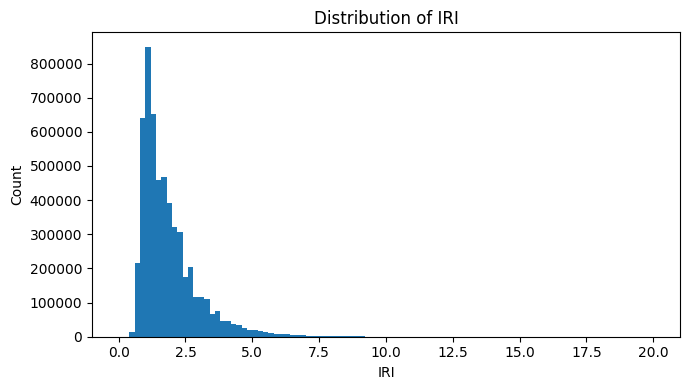

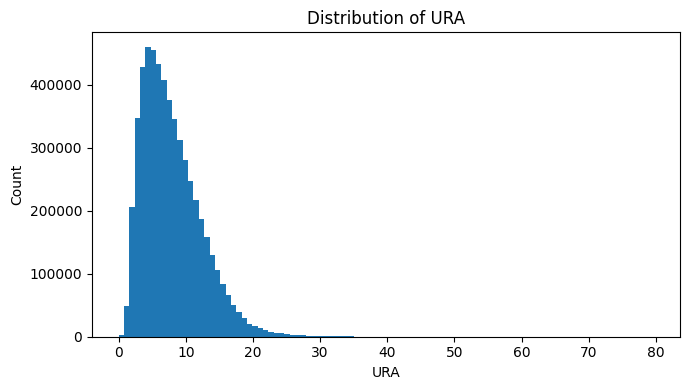

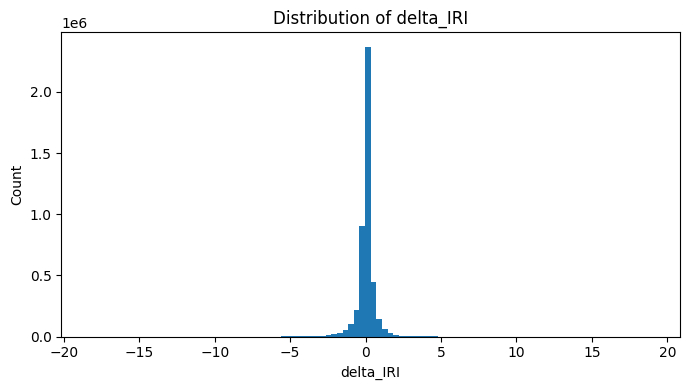

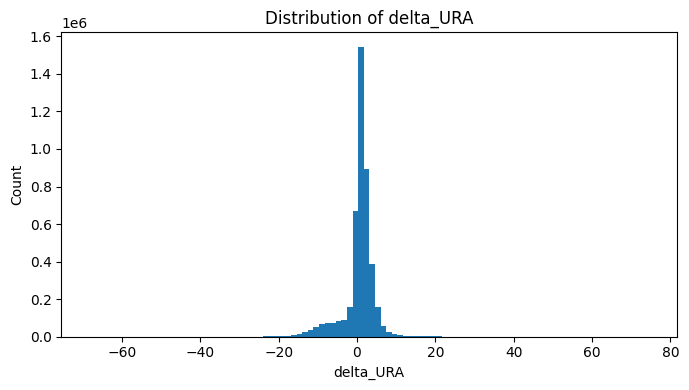

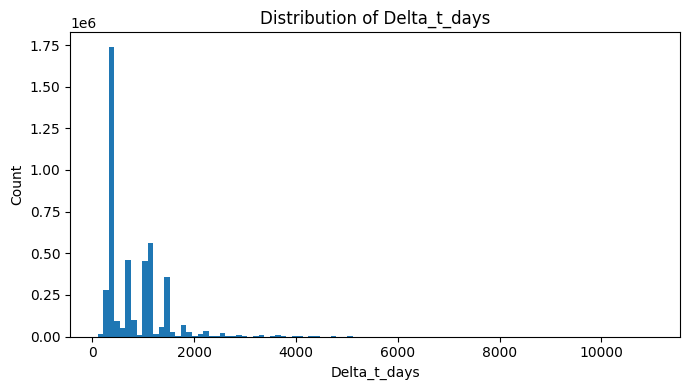

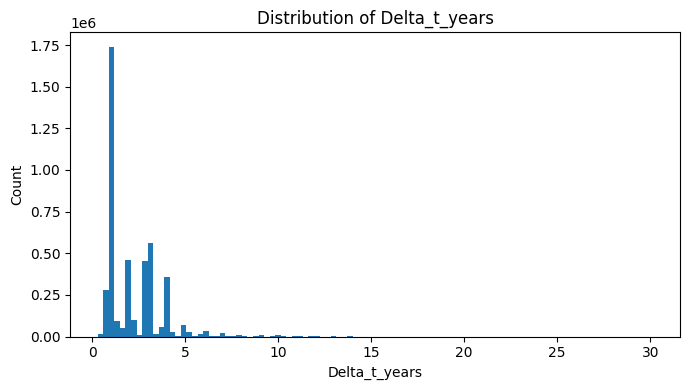

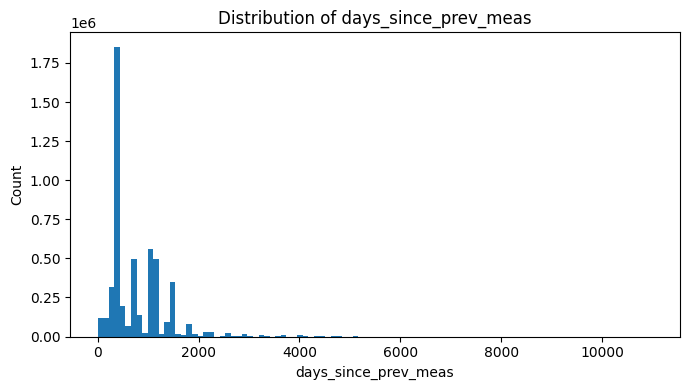

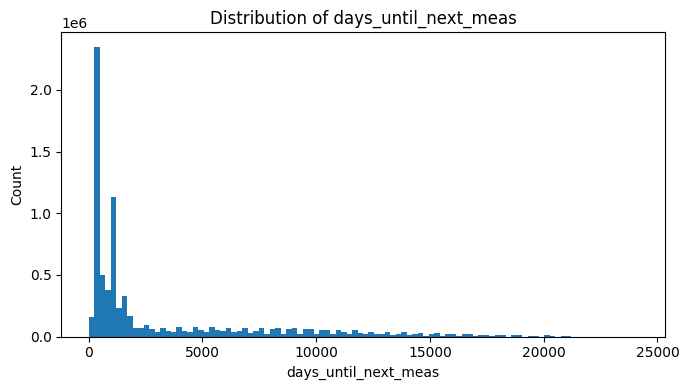

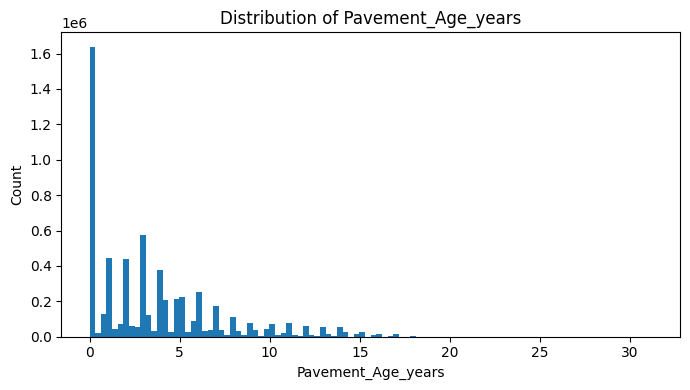

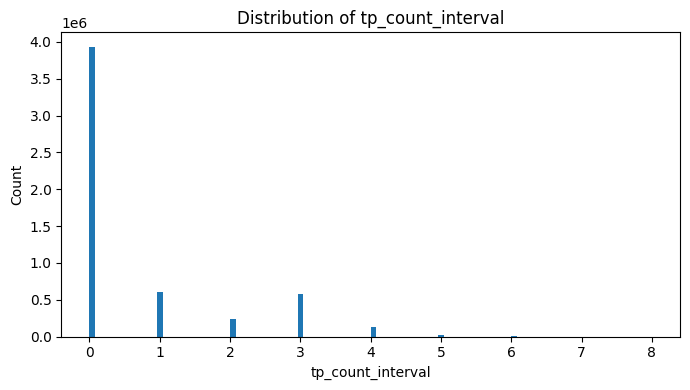

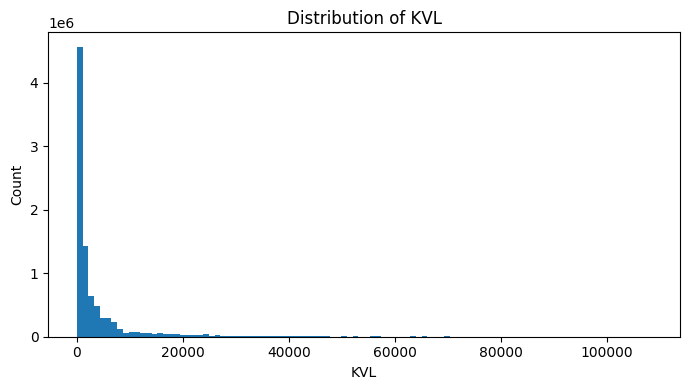

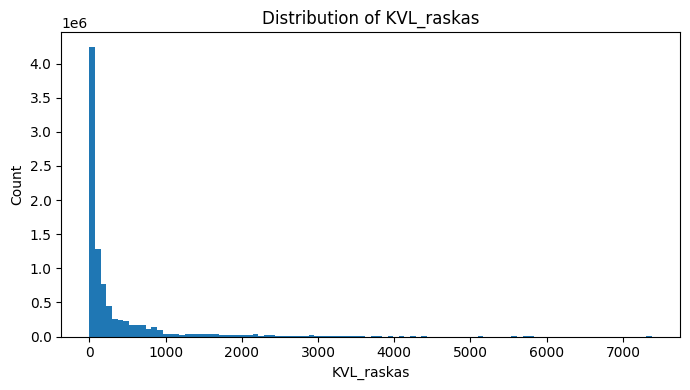

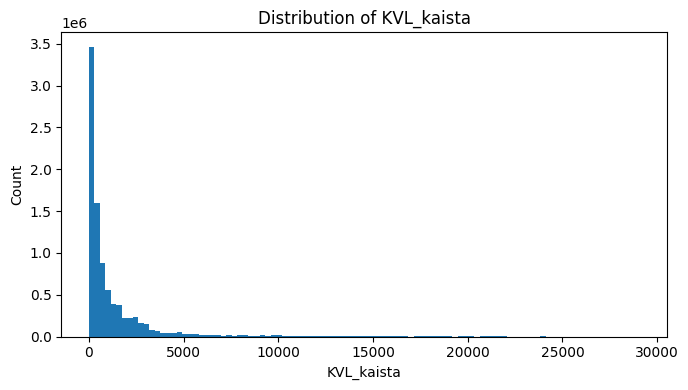

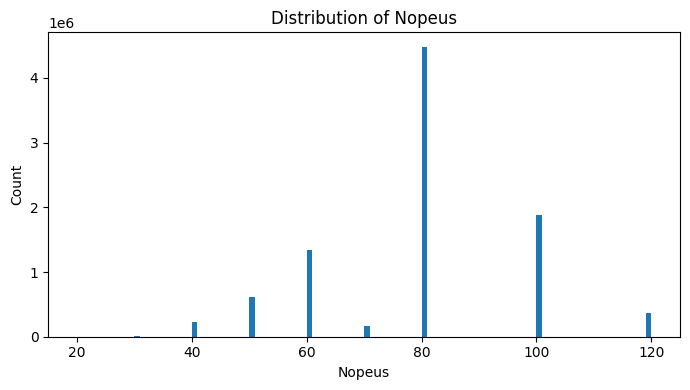

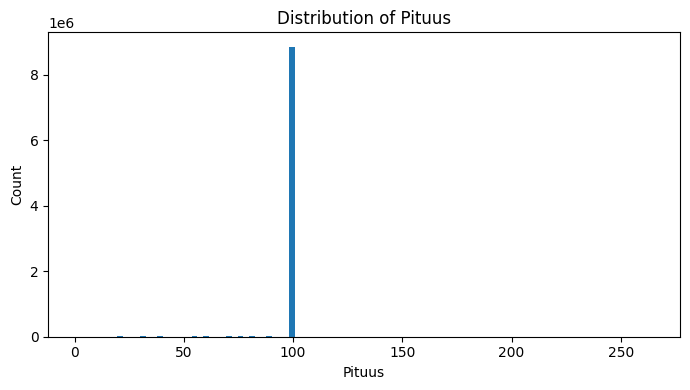

In [13]:
plot_cols = [
    "IRI", "URA",
    "delta_IRI", "delta_URA",
    "Delta_t_days", "Delta_t_years",
    "days_since_prev_meas", "days_until_next_meas",
    "Pavement_Age_years",
    "tp_count_interval",
    "KVL", "KVL_raskas", "KVL_kaista",
    "Nopeus", "Pituus",
]

for c in plot_cols:
    if c not in df.columns:
        continue

    s = pd.to_numeric(df[c], errors="coerce").dropna()
    if len(s) == 0:
        continue

    plt.figure(figsize=(7, 4))
    plt.hist(s, bins=100)
    plt.title(f"Distribution of {c}")
    plt.xlabel(c)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

### PTM-only distributions

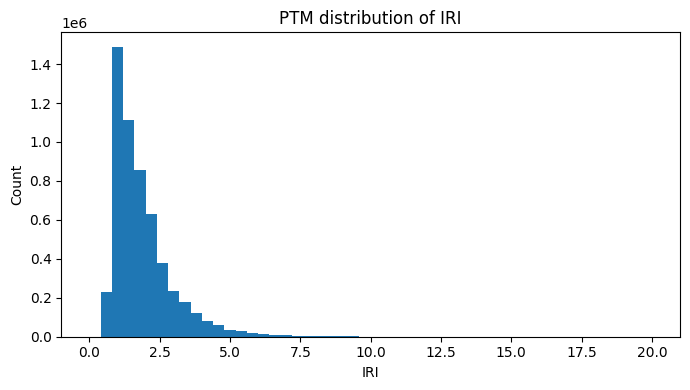

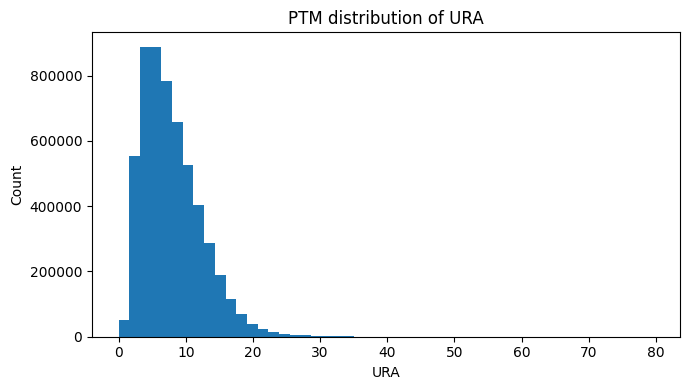

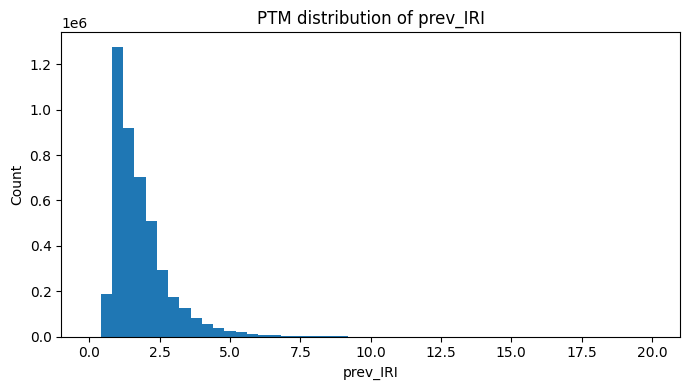

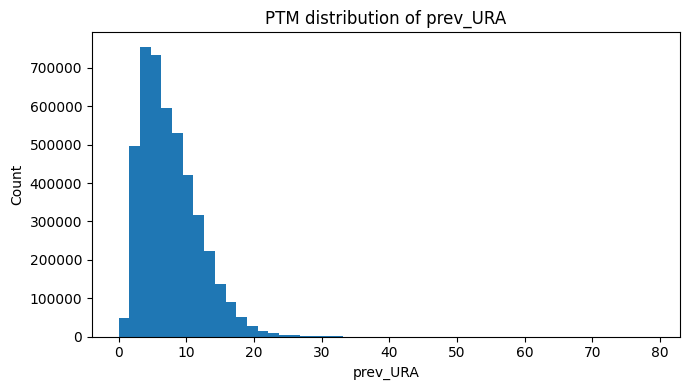

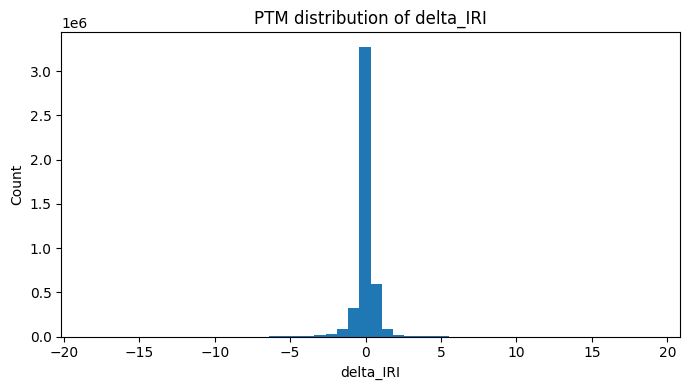

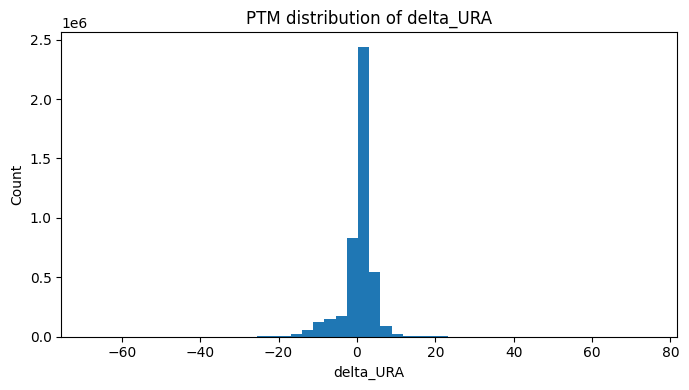

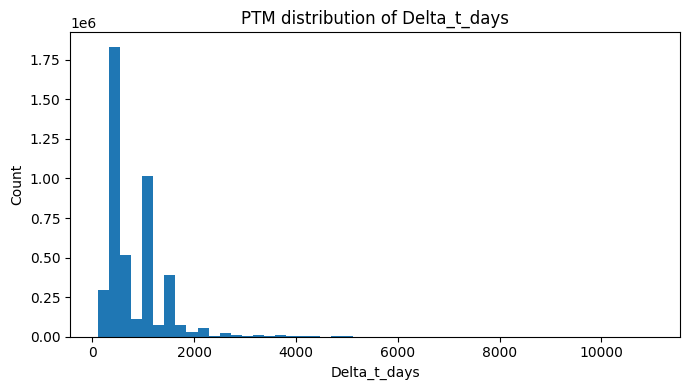

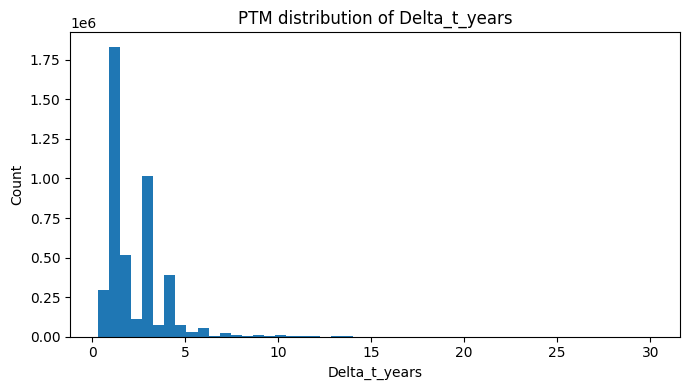

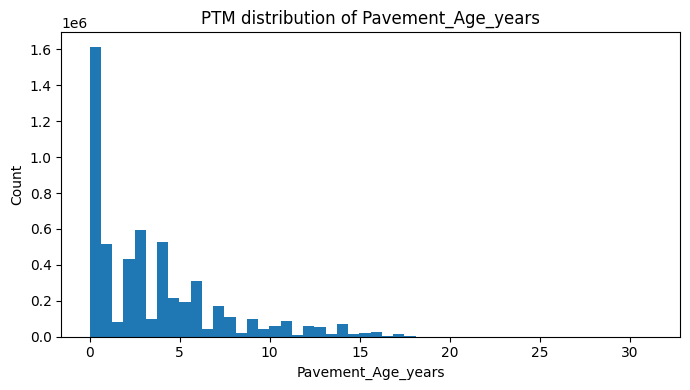

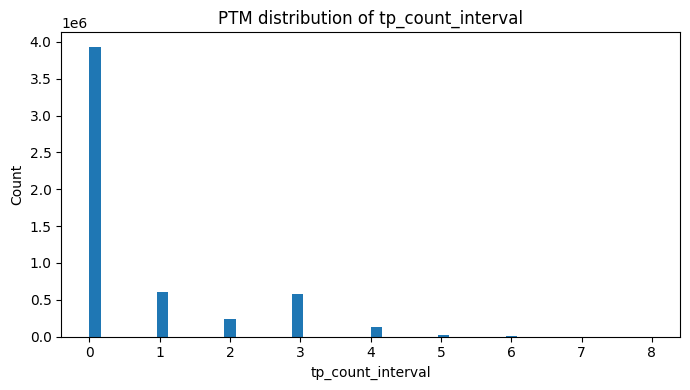

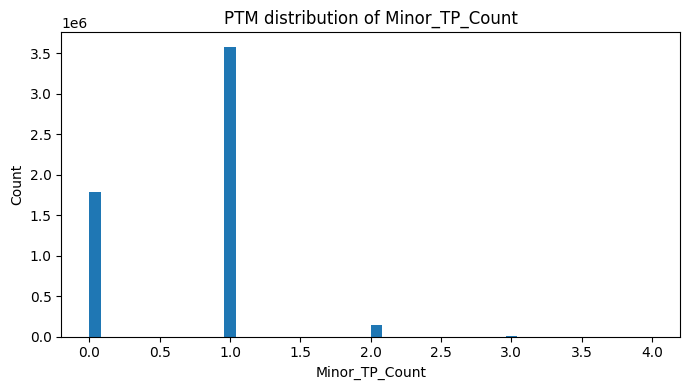

In [14]:
ptm = df[df["event_type"] == "PTM"].copy() if "event_type" in df.columns else df.copy()

ptm_plot_cols = [
    "IRI", "URA",
    "prev_IRI", "prev_URA",
    "delta_IRI", "delta_URA",
    "Delta_t_days", "Delta_t_years",
    "Pavement_Age_years",
    "tp_count_interval",
    "Minor_TP_Count",
]

for c in ptm_plot_cols:
    if c not in ptm.columns:
        continue

    s = pd.to_numeric(ptm[c], errors="coerce").dropna()
    if len(s) == 0:
        continue

    plt.figure(figsize=(7, 4))
    plt.hist(s, bins=50)
    plt.title(f"PTM distribution of {c}")
    plt.xlabel(c)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

### Event counts per segment and per lifecycle

Events per segment:


count    1.064380e+06
mean     8.523006e+00
std      4.018242e+00
min      1.000000e+00
25%      6.000000e+00
50%      7.000000e+00
75%      1.100000e+01
max      2.500000e+01
dtype: float64

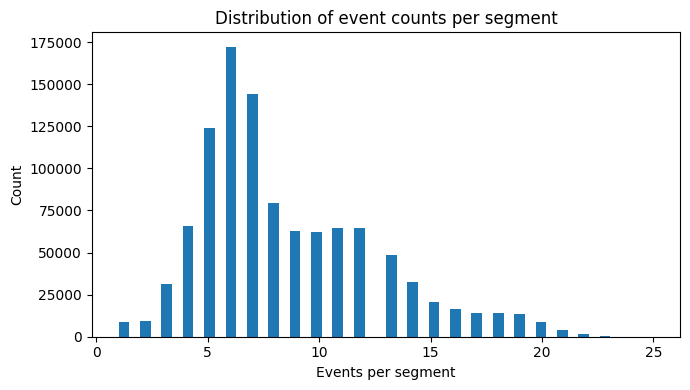

Events per lifecycle:


count    1.610446e+06
mean     3.828173e+00
std      2.230445e+00
min      1.000000e+00
25%      2.000000e+00
50%      3.000000e+00
75%      5.000000e+00
max      1.800000e+01
dtype: float64

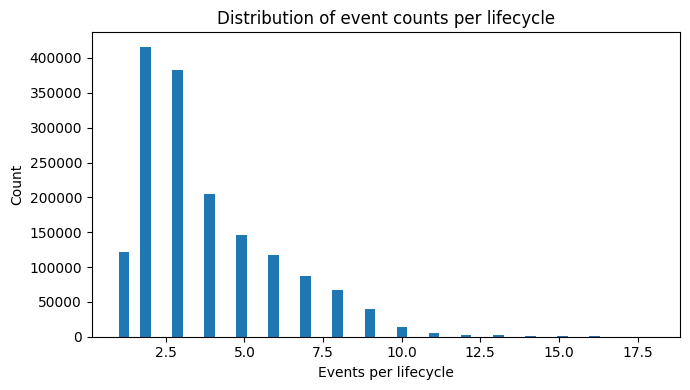

In [15]:
if "Segment_ID" in df.columns:
    seg_counts = df.groupby("Segment_ID").size().sort_values(ascending=False)
    print("Events per segment:")
    display(seg_counts.describe())

    plt.figure(figsize=(7, 4))
    plt.hist(seg_counts, bins=50)
    plt.title("Distribution of event counts per segment")
    plt.xlabel("Events per segment")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

if "Lifecycle_ID" in df.columns:
    lifecycle_counts = df.groupby("Lifecycle_ID").size().sort_values(ascending=False)
    print("Events per lifecycle:")
    display(lifecycle_counts.describe())

    plt.figure(figsize=(7, 4))
    plt.hist(lifecycle_counts, bins=50)
    plt.title("Distribution of event counts per lifecycle")
    plt.xlabel("Events per lifecycle")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

### Number of PTM and TP events per segment

,PTM,TP
Segment_ID,,
Epo_13291_0_11_2_3545_2_3600,0,2
Epo_13291_0_11_2_3600_2_3700,0,2
Epo_13291_0_11_2_3700_2_3724,0,2
Epo_13291_0_21_2_3545_2_3600,0,2
Epo_13291_0_21_2_3600_2_3700,0,2


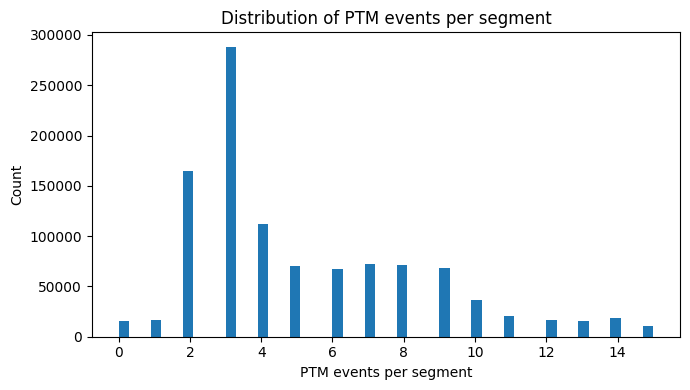

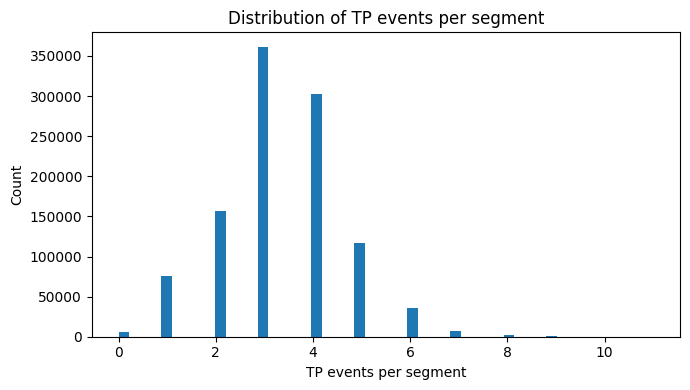

In [16]:
if {"Segment_ID", "event_type"}.issubset(df.columns):
    counts = (
        df.groupby(["Segment_ID", "event_type"])
          .size()
          .unstack(fill_value=0)
          .rename_axis(None, axis=1)
    )

    display(counts.head())

    for c in counts.columns:
        plt.figure(figsize=(7, 4))
        plt.hist(counts[c], bins=50)
        plt.title(f"Distribution of {c} events per segment")
        plt.xlabel(f"{c} events per segment")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

### Date coverage plots

event_type,PTM,TP
year_plot,,
2005,3477,97913
2006,21446,84515
2007,42033,77001
2008,54368,68683
2009,77038,83329
2010,262253,69164
2011,253981,57423
2012,260569,45344
2013,269515,50857


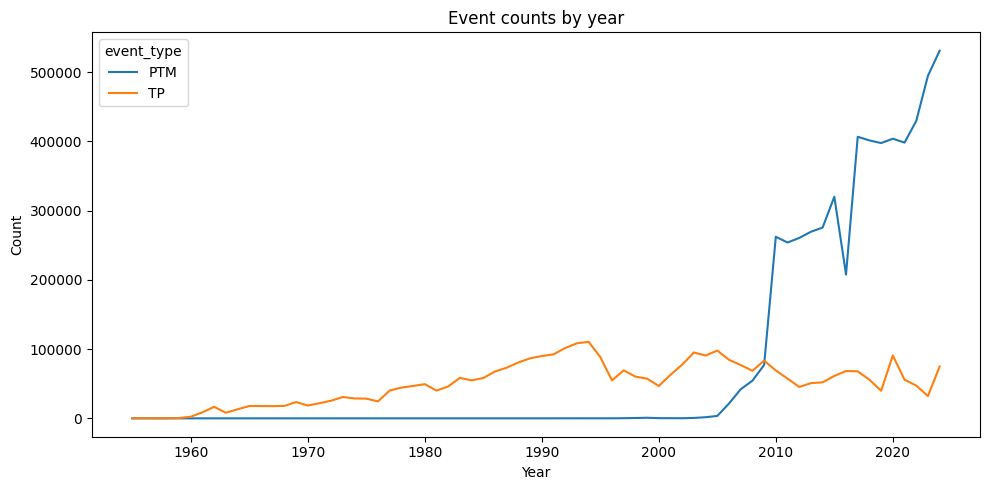

In [17]:
if "event_date" in df.columns:
    yearly = df.assign(year_plot=df["event_date"].dt.year).groupby(["year_plot", "event_type"]).size().unstack(fill_value=0)
    display(yearly.tail(20))

    yearly.plot(figsize=(10, 5))
    plt.title("Event counts by year")
    plt.xlabel("Year")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

### Correlation matrix for numeric columns

,IRI,URA,prev_IRI,prev_URA,delta_IRI,delta_URA,Delta_t_days,Delta_t_years,days_since_prev_meas,days_until_next_meas,Pavement_Age_years,tp_count_interval,Minor_TP_Count,cycle_num,KVL,KVL_raskas,KVL_kaista,Nopeus,Pituus
IRI,1.000000,0.219276,0.811092,0.084988,0.378955,0.176938,0.280621,0.280621,0.280621,0.272927,0.200576,-0.011266,0.245148,-0.269116,-0.237654,-0.282922,-0.250986,-0.360842,-0.132536
URA,0.219276,1.000000,0.107083,0.613779,0.218250,0.482115,-0.109986,-0.109986,-0.109986,-0.123472,0.220490,-0.185968,0.055091,-0.027819,0.094794,0.085635,0.154393,-0.016585,0.004998
prev_IRI,0.811092,0.107083,1.000000,0.173924,-0.233925,-0.068441,0.272927,0.272927,0.272927,0.279715,0.163161,0.043835,0.164997,-0.202650,-0.237533,-0.283604,-0.248594,-0.370411,-0.114080
prev_URA,0.084988,0.613779,0.173924,1.000000,-0.134873,-0.395757,-0.123472,-0.123472,-0.123472,-0.120175,-0.101957,0.313483,-0.148774,0.164894,0.119784,0.110884,0.185398,-0.004495,0.005418
delta_IRI,0.378955,0.218250,-0.233925,-0.134873,1.000000,0.403585,0.034496,0.034496,0.034496,0.050723,0.240916,-0.377603,0.179756,-0.169447,-0.029033,-0.033496,-0.031271,-0.034755,-0.014175
delta_URA,0.176938,0.482115,-0.068441,-0.395757,0.403585,1.000000,0.009104,0.009104,0.009104,0.013181,0.347618,-0.668548,0.282756,-0.271231,-0.042309,-0.045551,-0.044133,-0.034652,0.001212
Delta_t_days,0.280621,-0.109986,0.272927,-0.123472,0.034496,0.009104,1.000000,1.000000,1.000000,0.488141,0.330456,0.154981,0.140019,-0.163331,-0.291184,-0.317738,-0.296461,-0.204910,-0.022606
Delta_t_years,0.280621,-0.109986,0.272927,-0.123472,0.034496,0.009104,1.000000,1.000000,1.000000,0.488141,0.330456,0.154981,0.140019,-0.163331,-0.291184,-0.317738,-0.296461,-0.204910,-0.022606
days_since_prev_meas,0.280621,-0.109986,0.272927,-0.123472,0.034496,0.009104,1.000000,1.000000,1.000000,0.438728,0.309115,0.154981,0.140019,-0.146192,-0.290672,-0.317023,-0.298307,-0.206171,-0.024239
days_until_next_meas,0.272927,-0.123472,0.279715,-0.120175,0.050723,0.013181,0.488141,0.488141,0.438728,1.000000,-0.031357,0.239289,0.206474,-0.228361,-0.200804,-0.218694,-0.206754,-0.125212,-0.020172


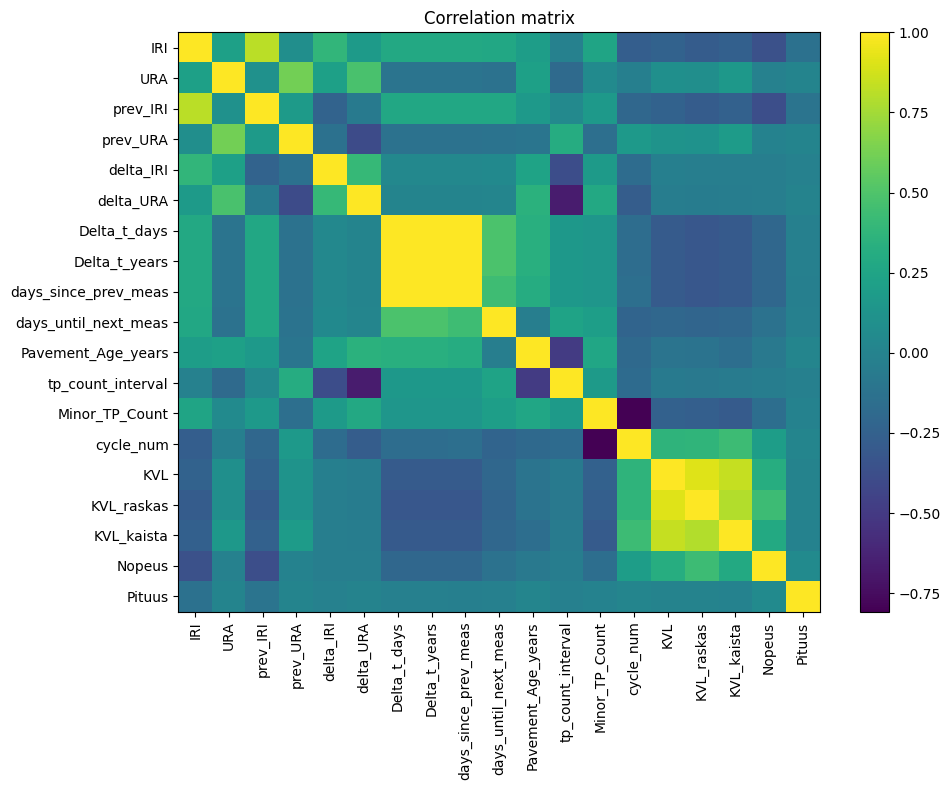

In [18]:
corr_cols = [
    "IRI", "URA",
    "prev_IRI", "prev_URA",
    "delta_IRI", "delta_URA",
    "Delta_t_days", "Delta_t_years",
    "days_since_prev_meas", "days_until_next_meas",
    "Pavement_Age_years",
    "tp_count_interval",
    "Minor_TP_Count",
    "cycle_num",
    "KVL", "KVL_raskas", "KVL_kaista",
    "Nopeus", "Pituus",
]

corr_cols = [c for c in corr_cols if c in df.columns]
corr_df = df[corr_cols].apply(pd.to_numeric, errors="coerce")

corr = corr_df.corr(numeric_only=True)
display(corr)

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar()
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

### Correlation matrix for PTM rows only

,IRI,URA,prev_IRI,prev_URA,delta_IRI,delta_URA,Delta_t_days,Delta_t_years,days_since_prev_meas,days_until_next_meas,Pavement_Age_years,tp_count_interval,Minor_TP_Count,cycle_num,KVL,KVL_raskas,KVL_kaista,Nopeus,Pituus
IRI,1.000000,0.219276,0.811092,0.084988,0.378955,0.176938,0.280621,0.280621,0.280621,0.272927,0.200576,-0.011266,0.245148,-0.269116,-0.237654,-0.282922,-0.250986,-0.360842,-0.132536
URA,0.219276,1.000000,0.107083,0.613779,0.218250,0.482115,-0.109986,-0.109986,-0.109986,-0.123472,0.220490,-0.185968,0.055091,-0.027819,0.094794,0.085635,0.154393,-0.016585,0.004998
prev_IRI,0.811092,0.107083,1.000000,0.173924,-0.233925,-0.068441,0.272927,0.272927,0.272927,0.279715,0.163161,0.043835,0.164997,-0.202650,-0.237533,-0.283604,-0.248594,-0.370411,-0.114080
prev_URA,0.084988,0.613779,0.173924,1.000000,-0.134873,-0.395757,-0.123472,-0.123472,-0.123472,-0.120175,-0.101957,0.313483,-0.148774,0.164894,0.119784,0.110884,0.185398,-0.004495,0.005418
delta_IRI,0.378955,0.218250,-0.233925,-0.134873,1.000000,0.403585,0.034496,0.034496,0.034496,0.050723,0.240916,-0.377603,0.179756,-0.169447,-0.029033,-0.033496,-0.031271,-0.034755,-0.014175
delta_URA,0.176938,0.482115,-0.068441,-0.395757,0.403585,1.000000,0.009104,0.009104,0.009104,0.013181,0.347618,-0.668548,0.282756,-0.271231,-0.042309,-0.045551,-0.044133,-0.034652,0.001212
Delta_t_days,0.280621,-0.109986,0.272927,-0.123472,0.034496,0.009104,1.000000,1.000000,1.000000,0.488141,0.330456,0.154981,0.140019,-0.163331,-0.291184,-0.317738,-0.296461,-0.204910,-0.022606
Delta_t_years,0.280621,-0.109986,0.272927,-0.123472,0.034496,0.009104,1.000000,1.000000,1.000000,0.488141,0.330456,0.154981,0.140019,-0.163331,-0.291184,-0.317738,-0.296461,-0.204910,-0.022606
days_since_prev_meas,0.280621,-0.109986,0.272927,-0.123472,0.034496,0.009104,1.000000,1.000000,1.000000,0.488141,0.330456,0.154981,0.140019,-0.163331,-0.291184,-0.317738,-0.296461,-0.204910,-0.022606
days_until_next_meas,0.272927,-0.123472,0.279715,-0.120175,0.050723,0.013181,0.488141,0.488141,0.488141,1.000000,0.007452,0.239289,0.206474,-0.237737,-0.291184,-0.317738,-0.296461,-0.204910,-0.022606


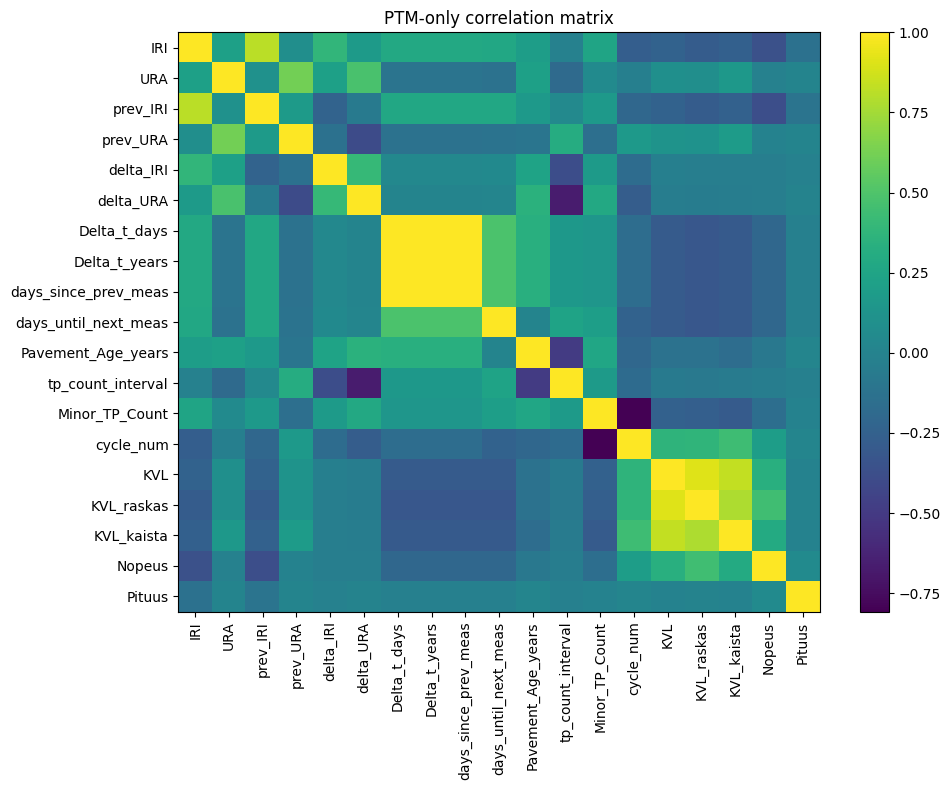

In [19]:
ptm_corr_cols = [c for c in corr_cols if c in ptm.columns]
ptm_corr_df = ptm[ptm_corr_cols].apply(pd.to_numeric, errors="coerce")
ptm_corr = ptm_corr_df.corr(numeric_only=True)

display(ptm_corr)

plt.figure(figsize=(10, 8))
plt.imshow(ptm_corr, aspect="auto")
plt.xticks(range(len(ptm_corr.columns)), ptm_corr.columns, rotation=90)
plt.yticks(range(len(ptm_corr.index)), ptm_corr.index)
plt.colorbar()
plt.title("PTM-only correlation matrix")
plt.tight_layout()
plt.show()

### Boolean flag summaries

In [20]:
bool_like_cols = [
    "has_TP_interval",
    "is_minor_treatment",
    "is_major_reset",
    "is_phantom_reset",
]

for c in bool_like_cols:
    if c in df.columns:
        print(f"\n=== {c} ===")
        display(df[c].value_counts(dropna=False))

        if "event_type" in df.columns:
            cross = pd.crosstab(df["event_type"], df[c], dropna=False)
            print("By event_type:")
            display(cross)


=== has_TP_interval ===


has_TP_interval
False    3933703
<NA>     3555858
True     1582156
Name: count, dtype: Int64

By event_type:


has_TP_interval,False,True,<NA>
event_type,,,
PTM,3933703,1582156,0
TP,0,0,3555858



=== is_minor_treatment ===


...

is_major_reset,False,True,<NA>
event_type,,,
PTM,4954490,561369,0
TP,0,0,3555858



=== is_phantom_reset ===


is_phantom_reset
False    5434024
<NA>     3555858
True       81835
Name: count, dtype: Int64

By event_type:


is_phantom_reset,False,True,<NA>
event_type,,,
PTM,5434024,81835,0
TP,0,0,3555858


### Useful integrity checks

In [21]:
checks = {}

if "Segment_ID" in df.columns:
    checks["missing Segment_ID"] = df["Segment_ID"].isna().sum()

if "event_type" in df.columns:
    checks["invalid event_type"] = (~df["event_type"].isin(["PTM", "TP"])).sum()

if "event_order" in df.columns:
    checks["invalid event_order"] = (~df["event_order"].isin([0, 1])).sum()

if {"event_type", "ptm_idx"}.issubset(df.columns):
    checks["PTM rows missing ptm_idx"] = ((df["event_type"] == "PTM") & (df["ptm_idx"].isna())).sum()

if {"event_type", "tp_idx"}.issubset(df.columns):
    checks["TP rows missing tp_idx"] = ((df["event_type"] == "TP") & (df["tp_idx"].isna())).sum()

if {"event_type", "URA"}.issubset(df.columns):
    checks["PTM rows missing URA"] = ((df["event_type"] == "PTM") & (df["URA"].isna())).sum()

if {"event_type", "IRI"}.issubset(df.columns):
    checks["PTM rows missing IRI"] = ((df["event_type"] == "PTM") & (df["IRI"].isna())).sum()

if {"event_type", "Tp_pinta"}.issubset(df.columns):
    checks["TP rows missing Tp_pinta"] = ((df["event_type"] == "TP") & (df["Tp_pinta"].isna())).sum()

if {"event_type", "Tp_tyomen"}.issubset(df.columns):
    checks["TP rows missing Tp_tyomen"] = ((df["event_type"] == "TP") & (df["Tp_tyomen"].isna())).sum()

pd.Series(checks, name="count")

missing Segment_ID                0
invalid event_type                0
invalid event_order               0
PTM rows missing ptm_idx          0
TP rows missing tp_idx            0
PTM rows missing URA            626
PTM rows missing IRI           5342
TP rows missing Tp_pinta     266243
TP rows missing Tp_tyomen    644590
Name: count, dtype: int64